![Imgur](https://i.imgur.com/h4PPC71.png)
#**18-modul. Amaliyot. Customer Churn**
# 18.6. Modul boʻyicha yakuniy amaliy vazifa

**Bu vazifa orqali data sayns jarayoni:**

✔️ maʼlumot tayyorlash;

  ✔️ model qurish;

  ✔️ baholash;

  ✔️ natijalarni tahlil qilish
  kabi koʻnikmalarga ega boʻlasiz.

#**Vazifa: bank mijozlarining noroziligini bashorat qilish**

**Vazifa tavsifi**

Sizga bank mijozlari haqida maʼlumotlar toʻplami berilgan. Maqsad – qaysi mijozlar bank xizmatlaridan voz kechishini (churn) oldindan bashorat qilish. Bank bu orqali oʻz mijozlarini ushlab qolish strategiyalarini yaxshilashi mumkin.

**Maʼlumotlar toʻplami**

Kaggle platformasidagi Churn Modelling maʼlumotlar toʻplamidan foydalanamiz. Ushbu toʻplamda 10 000 ta mijozning quyidagi maʼlumotlari mavjud:

- mijoz identifikatori (RowNumber, CustomerId, Surname);
- geografik joylashuvi (Geography);
- jinsi (Gender);
- yoshi (Age);
- kredit balli (CreditScore);
- yillik daromadi (EstimatedSalary);
- bankda qancha vaqtdan beri mijoz ekani (Tenure);
- qancha mahsulotdan foydalanishi (NumOfProducts);
- faoliyati (HasCrCard, IsActiveMember);
- balans (Balance);
- prognoz qilish holati, churn (Exited) – maqsadli oʻzgaruvchi.

**Topshiriqlar**

1. **Maʼlumotlarni tahlil qilish va tozalash:**
   - Maʼlumotlardagi boʻsh qiymatlar va anomaliyalarni aniqlang hamda tozalang.
   - Kategorik oʻzgaruvchilarni raqamli koʻrinishga oʻtkazing (masalan, one-hot encoding yordamida).

2. **Maʼlumotlarni boʻlish:**
   - Maʼlumotlarni training va test toʻplamlariga ajrating (masalan, 80% training, 20% test).

3. **Model qurish:**
   - Quyidagi algoritmlar yordamida modellarni yarating:
     - Logistic Regression
     - Support Vector Machine (SVM)
     - Decision Tree
     - Random Forest
     - XGBoost

4. **Modellarni baholash:**
   - Har bir model uchun quyidagi koʻrsatkichlarni hisoblang:
     - Aniqlik (Accuracy)
     - Toʻgʻrilik (Precision)
     - Recall
     - F1-score

5. **Natijalarni tahlil qilish:**
   - Olingan natijalarni solishtiring va qaysi model eng yaxshi ishlashini aniqlang.
   - Eng yaxshi model asosida bankka mijozlarni ushlab qolish boʻyicha tavsiyalar bering.
---

###*** ESLATMA**. *Ushbu amaliy vazifada siz oʻtmagan mavzulardan ham savollar va vazifalar boʻlishi mumkin! Bu savollarni mustaqil oʻrganishingiz kerak boʻladi. Bunday vazifalar mustaqil izlanish koʻnikmangizni oshirish uchun tayyorlandi!*

In [2]:
import pandas as pd
import numpy as np
import sklearn

url = "https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Churn_Modelling.xls"
df = pd.read_csv(url, index_col='RowNumber')
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


import needed libraries

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score

#**Task 1**

#Exploratory Data Analysis (EDA) and Data Cleaning

In [ ]:
df.info() # so it has no null values

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


##Visualisation

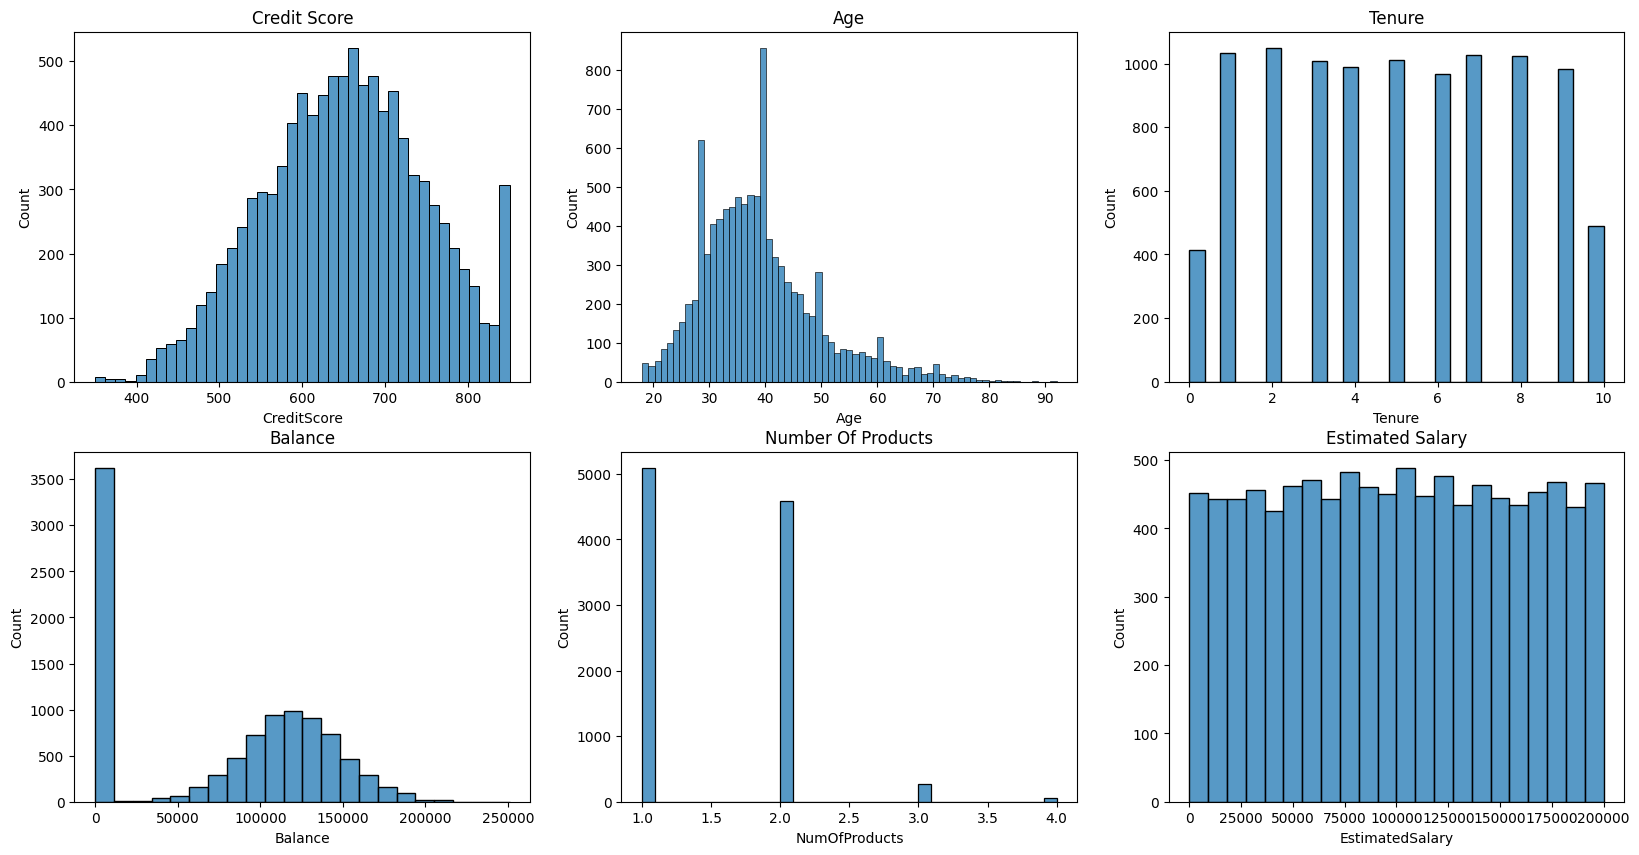

In [ ]:
fig, axes = plt.subplots(2,3, figsize = (20, 10))

#Credit Score
sns.histplot(data = df, x = 'CreditScore', ax = axes[0,0])
axes[0,0].set_title('Credit Score')

#Age
sns.histplot(data = df, x = 'Age', ax = axes[0,1])
axes[0,1].set_title('Age')

#Tenure
sns.histplot(data = df, x = 'Tenure', ax = axes[0,2])
axes[0,2].set_title('Tenure')

#Balance
sns.histplot(data = df, x = 'Balance', ax = axes[1,0])
axes[1,0].set_title('Balance')

#Number Of Products
sns.histplot(data = df, x = 'NumOfProducts', ax = axes[1,1])
axes[1,1].set_title('Number Of Products')

#Estimated Salary
sns.histplot(data = df, x = 'EstimatedSalary', ax = axes[1,2])
axes[1,2].set_title('Estimated Salary')

plt.show()

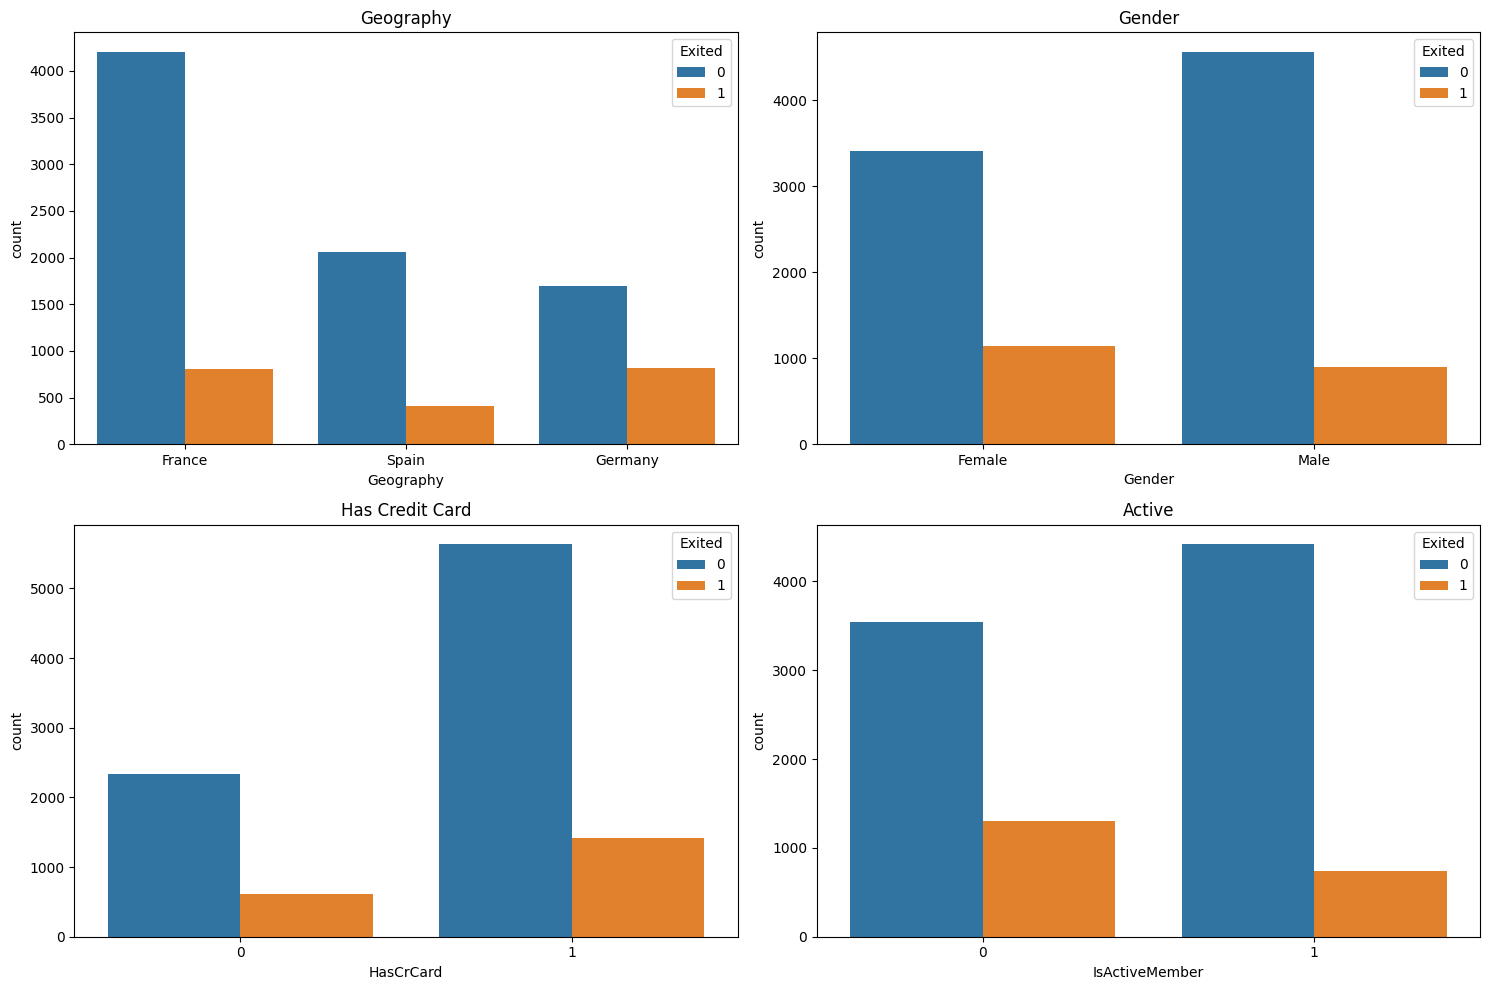

In [ ]:
fig, axes = plt.subplots(2,2, figsize = (15, 10))

#Geography
sns.countplot(data = df, x = 'Geography', hue = 'Exited', ax = axes[0,0])
axes[0,0].set_title('Geography')

#Gender
sns.countplot(data = df, x = 'Gender', hue = 'Exited', ax = axes[0,1])
axes[0,1].set_title('Gender')

#Has Credit Card
sns.countplot(data = df, x = 'HasCrCard', hue = 'Exited', ax = axes[1,0])
axes[1,0].set_title('Has Credit Card')

#Is Active Member
sns.countplot(data = df, x = 'IsActiveMember', hue = 'Exited', ax = axes[1,1])
axes[1,1].set_title('Active')
plt.tight_layout()
plt.show()

Correlation of numeric columns

In [ ]:
df.corrwith(df['Exited'], numeric_only = True).abs().sort_values(ascending=False)

,0
Exited,1.000000
Age,0.285323
IsActiveMember,0.156128
Balance,0.118533
NumOfProducts,0.047820
CreditScore,0.027094
Tenure,0.014001
EstimatedSalary,0.012097
HasCrCard,0.007138
CustomerId,0.006248


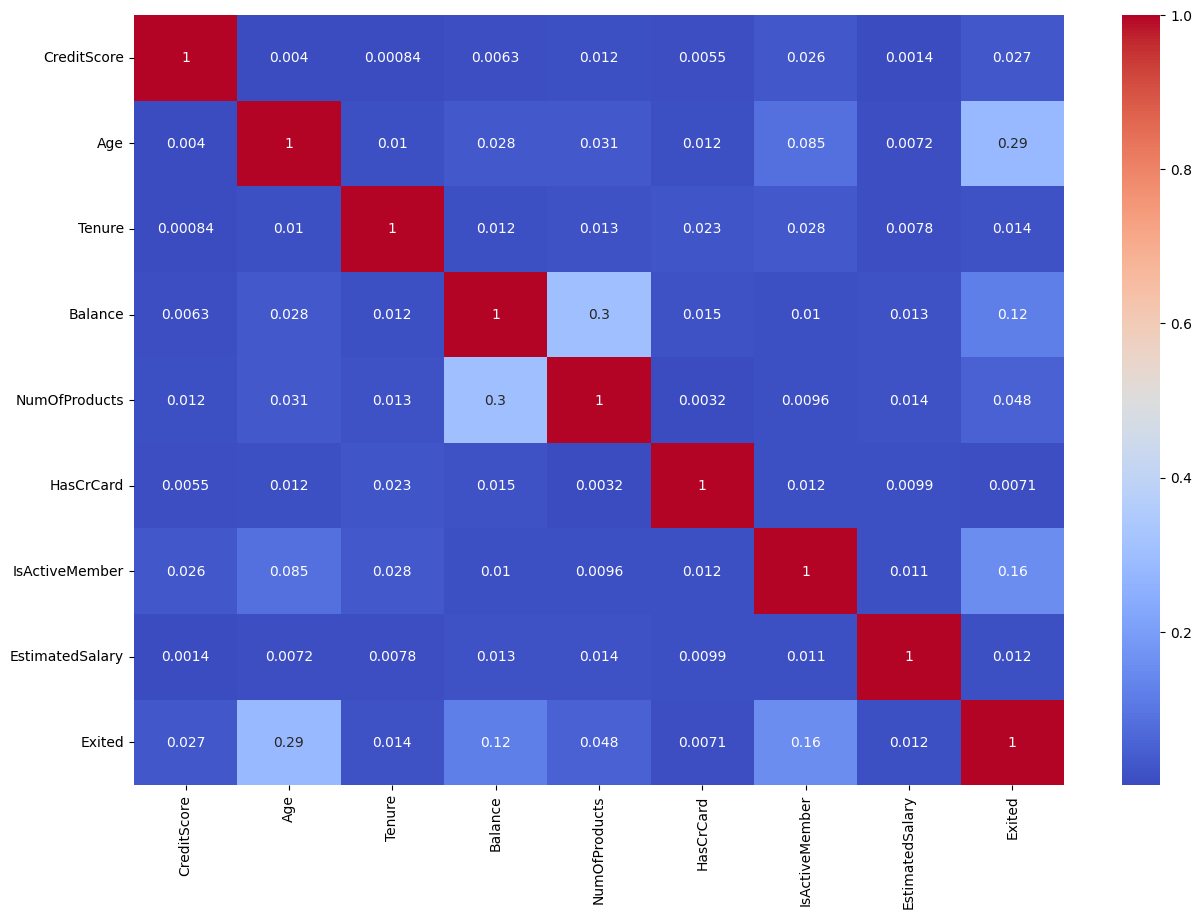

In [ ]:
corr = df.corr(numeric_only=True).abs()
plt.figure(figsize = (15,10))
sns.heatmap(corr, cmap = 'coolwarm', annot = True)
plt.show()

In [ ]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


Histogram of Exited


In [ ]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


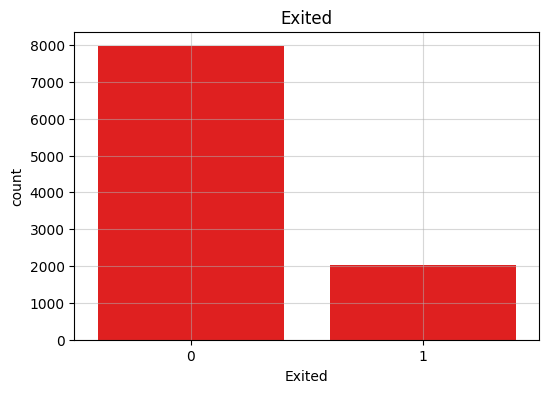

In [11]:
plt.figure(figsize = (6,4))
sns.countplot(data = df, x = 'Exited', color='r')
plt.title('Exited')
plt.grid(alpha = 0.5)
plt.show()

##Data processing

In [ ]:
# Drop customer ID and Surname columns, because they are useless
df = df.drop(['CustomerId','Surname'], axis = 1)

In [ ]:
# get_dummies()
encoded = pd.get_dummies(df).astype(float)
encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
RowNumber,,,,,,,,,,,,,,
1,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0,1.0,0.0,0.0,1.0,0.0
2,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0,0.0,0.0,1.0,1.0,0.0
3,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0,1.0,0.0,0.0,1.0,0.0
4,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0,1.0,0.0,0.0,1.0,0.0
5,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0,0.0,0.0,1.0,1.0,0.0


#**Task 2**

##Train Test split

In [ ]:
# Split train and test sets
X = encoded.drop('Exited', axis = 1)
y = encoded['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.2, random_state = 42)

In [ ]:
# SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

#**Task 3**
#Machine Learning

##Logistic Regression

Accuracy Score 0.714
Recall Score: 0.6977886977886978
Precision Score: 0.3874488403819918
F1 Score: 0.4982456140350877
ROC_AUC score: 0.7774199469114724
Classification report:
               precision    recall  f1-score   support

         0.0       0.90      0.72      0.80      1593
         1.0       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



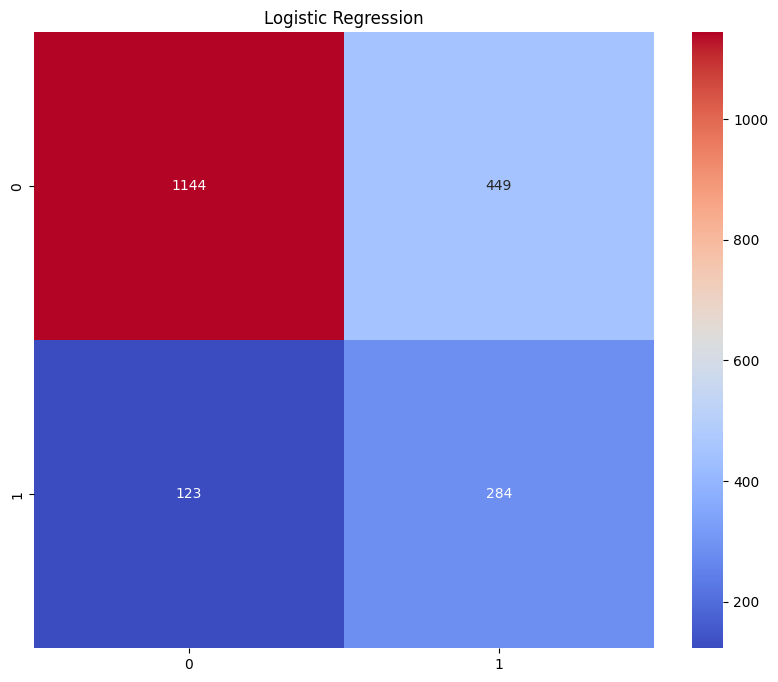

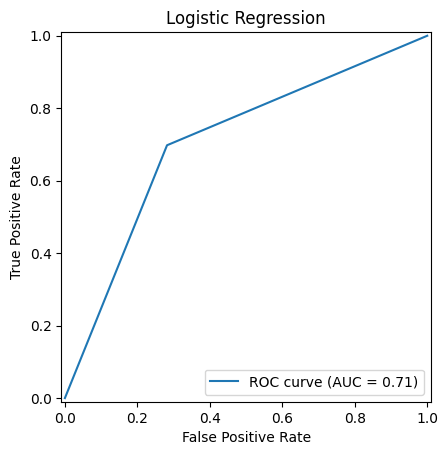

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train_res)

y_pred = log_reg.predict(X_test_scaled)

# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = log_reg.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("Logistic Regression")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("Logistic Regression")
plt.show()

##SVM

Accuracy Score 0.8505
Recall Score: 0.5528255528255528
Precision Score: 0.6578947368421053
F1 Score: 0.6008010680907877
ROC_AUC score: 0.8386953980174319
Classification report:
               precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      1593
         1.0       0.66      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.85      2000



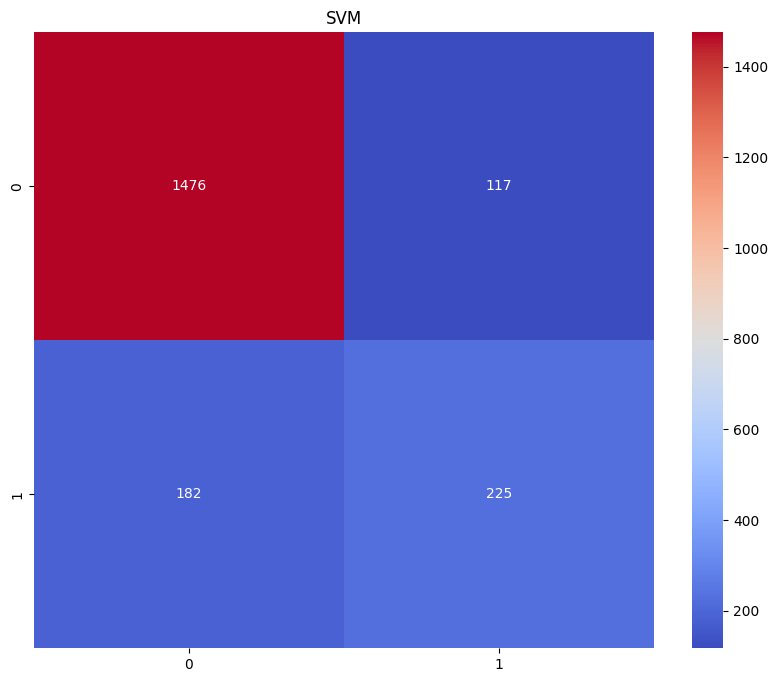

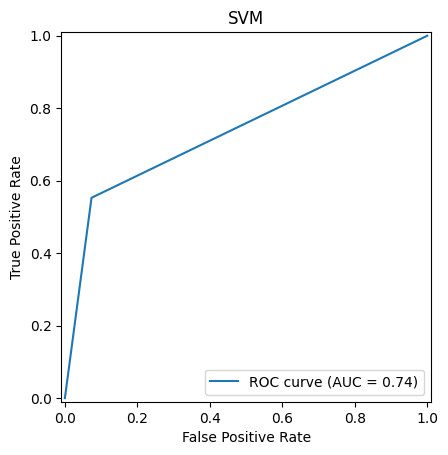

In [ ]:
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train_res)

y_pred = svm.predict(X_test_scaled)

# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = svm.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("SVM")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("SVM")
plt.show()

##Decision Tree

In [ ]:
param_grids = {'max_depth' : [10,12,15,20,30,40,50]}
tree_gscv = GridSearchCV(DecisionTreeClassifier(), param_grids, cv=5)
tree_gscv.fit(X_train_scaled, y_train_res)

tree_gscv.best_params_

{'max_depth': 12}

In [ ]:
param_grids = {'min_samples_split' : np.arange(2,15)}
tree_gscv = GridSearchCV(DecisionTreeClassifier(max_depth = 12), param_grids, cv=5)
tree_gscv.fit(X_train_scaled, y_train_res)

tree_gscv.best_params_

{'min_samples_split': np.int64(13)}

In [ ]:
param_grids = {'min_samples_leaf' : np.arange(2,20)}
tree_gscv = GridSearchCV(DecisionTreeClassifier(max_depth=12, min_samples_split=13), param_grids, cv=5)
tree_gscv.fit(X_train_scaled, y_train_res)

tree_gscv.best_params_

{'min_samples_leaf': np.int64(11)}

Accuracy Score 0.833
Recall Score: 0.48402948402948404
Precision Score: 0.6137071651090342
F1 Score: 0.5412087912087912
ROC_AUC score: 0.8052150764015171
Classification report:
               precision    recall  f1-score   support

         0.0       0.87      0.92      0.90      1593
         1.0       0.61      0.48      0.54       407

    accuracy                           0.83      2000
   macro avg       0.74      0.70      0.72      2000
weighted avg       0.82      0.83      0.83      2000



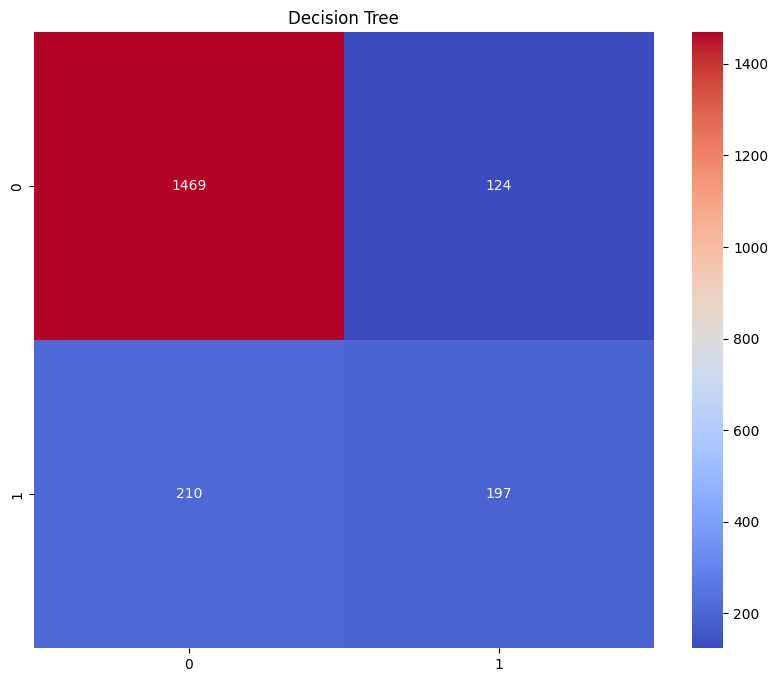

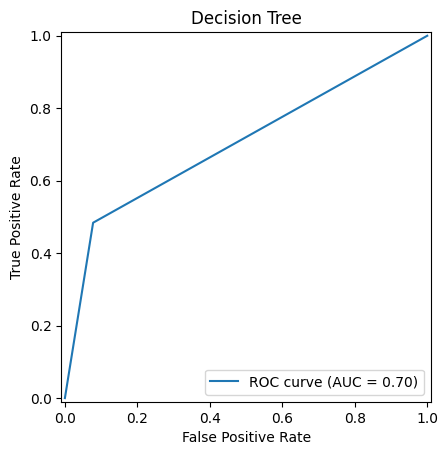

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=12, min_samples_split=13, max_features = 9)
tree_model.fit(X_train_scaled, y_train_res)

y_pred = tree_model.predict(X_test_scaled)

# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = tree_model.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("Decision Tree")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("Decision Tree")
plt.show()

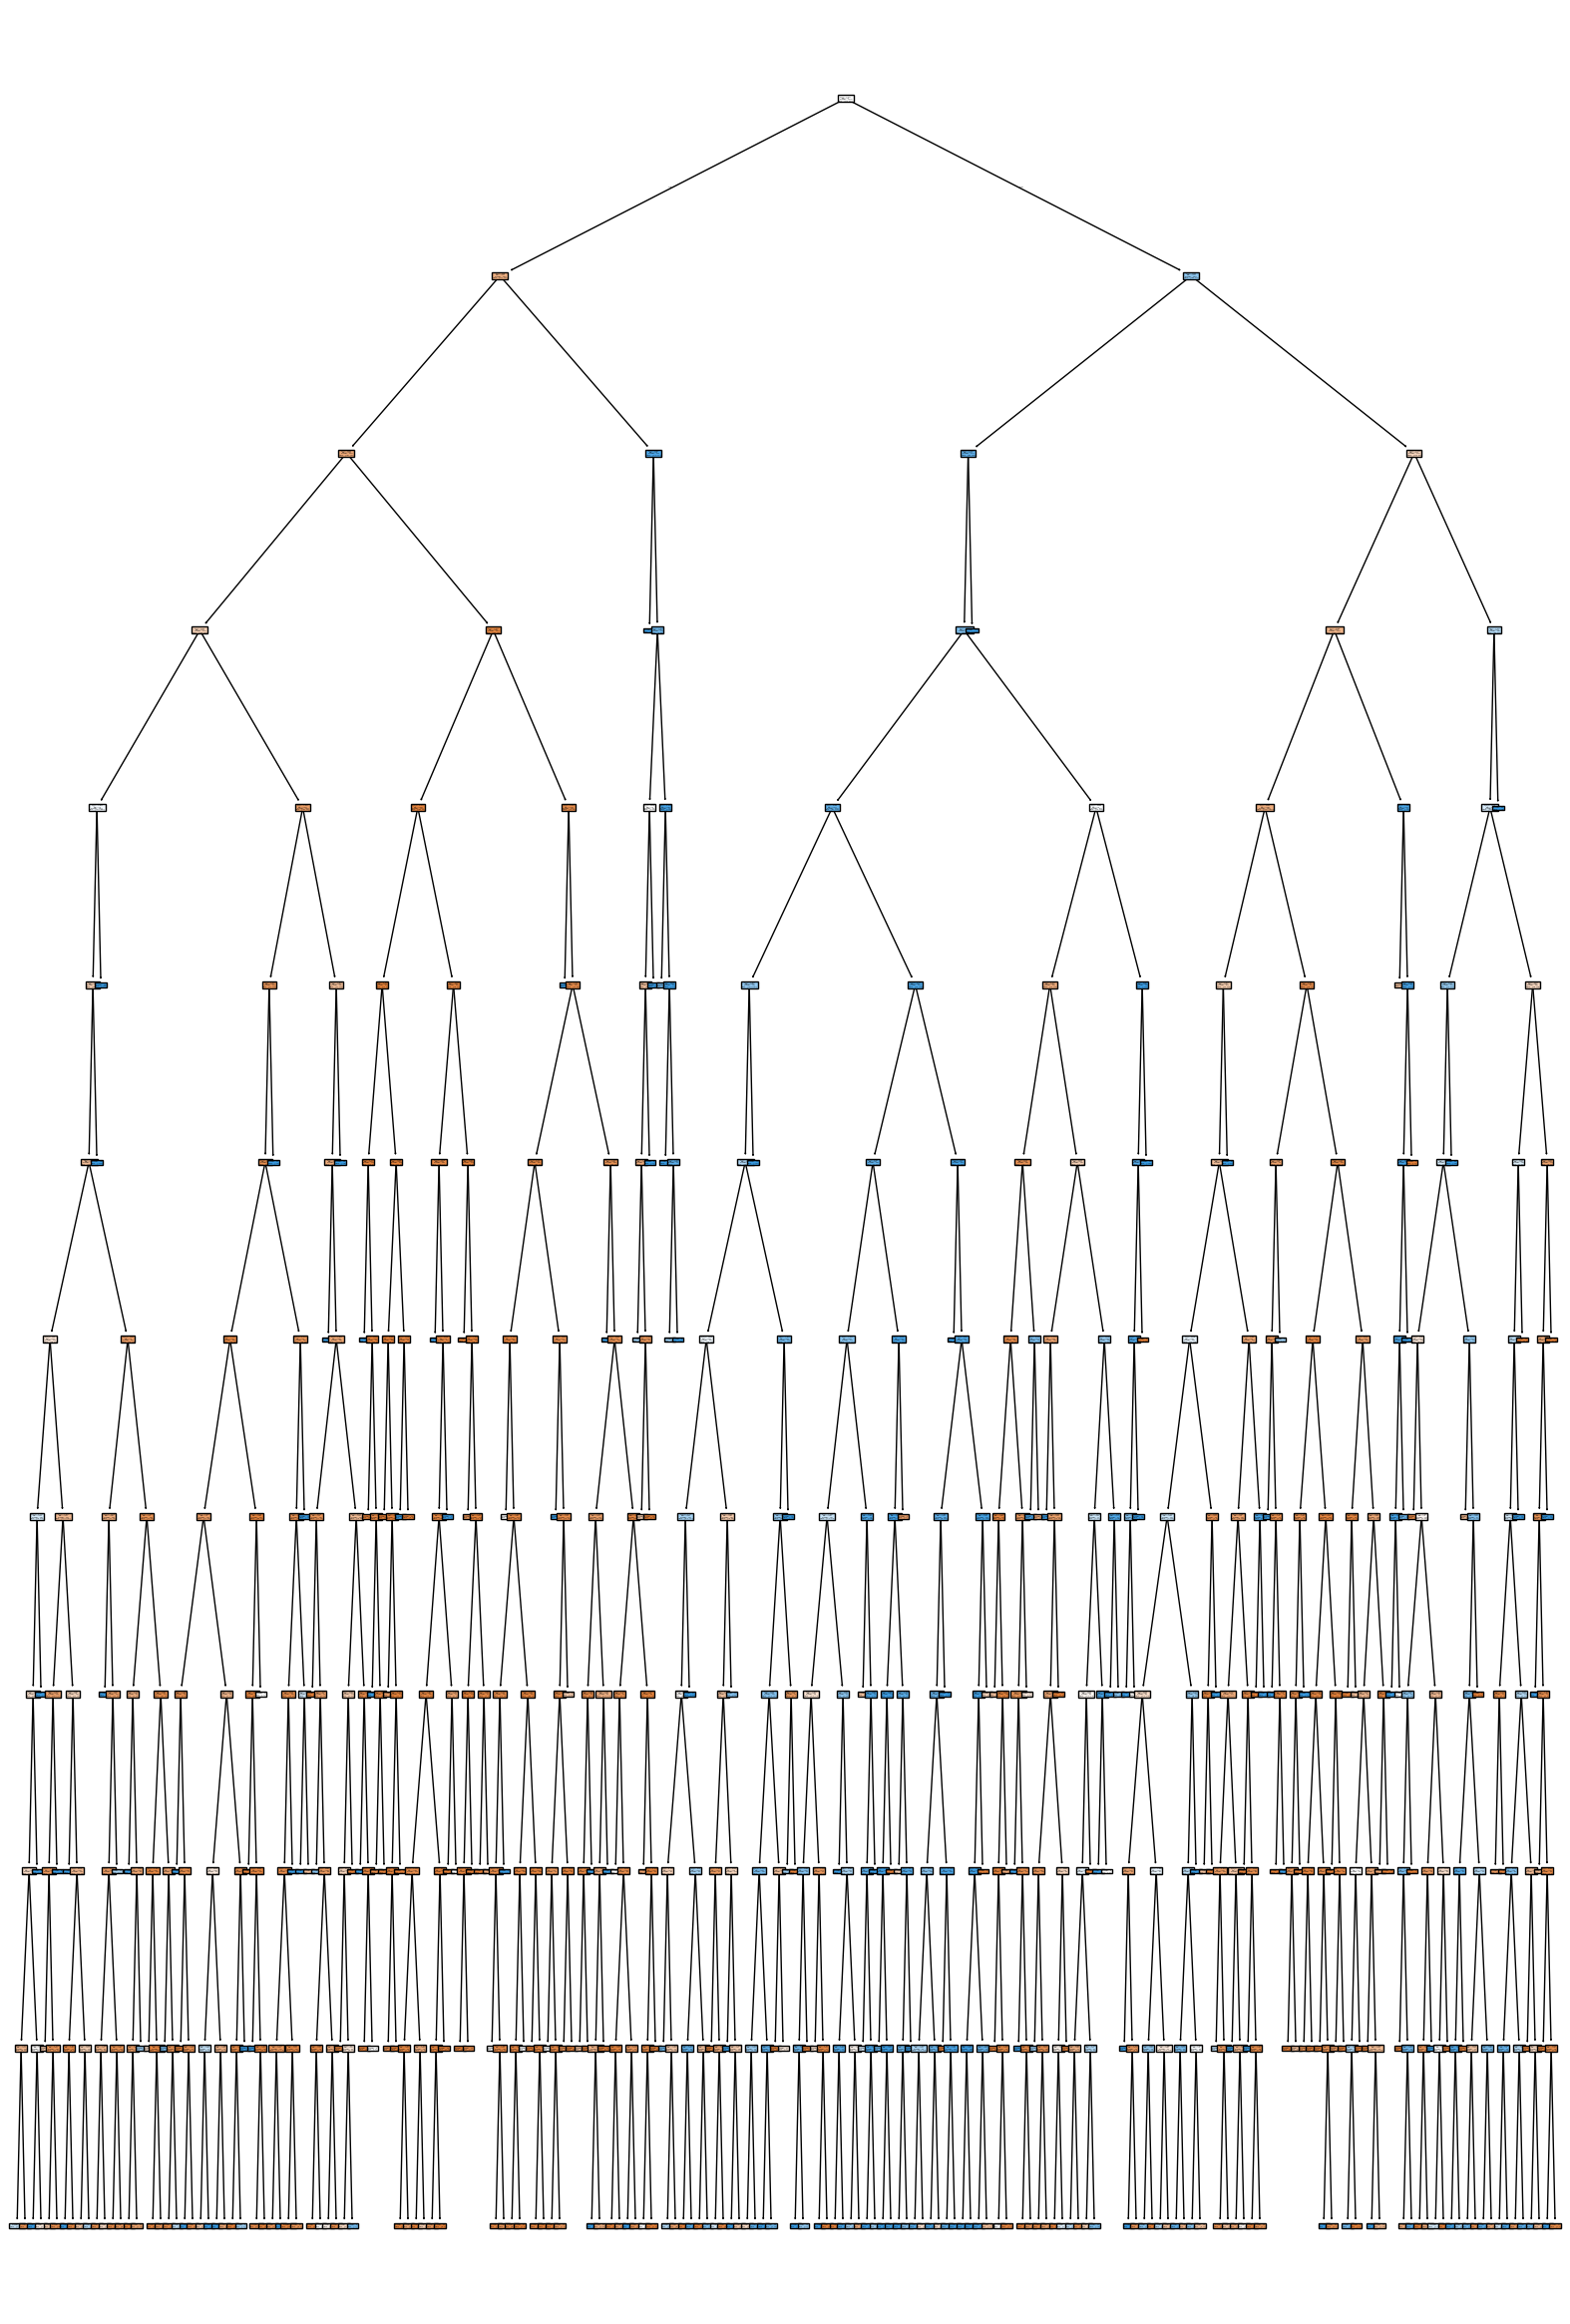

In [ ]:
#Tree plot
plt.figure(figsize = (20, 30))
plot_tree(tree_model, filled = True)
plt.show()

##Random Forest

In [ ]:
param_grids = {'max_depth' : [10,12,15,20,30,40,50]}
tree_gscv = GridSearchCV(RandomForestClassifier(), param_grids, cv=5)
tree_gscv.fit(X_train_scaled, y_train_res)

tree_gscv.best_params_

{'max_depth': 30}

In [ ]:
param_grids = {'min_samples_split' : np.arange(2,30)}
tree_gscv = GridSearchCV(DecisionTreeClassifier(max_depth = 20), param_grids, cv=5)
tree_gscv.fit(X_train_scaled, y_train_res)

tree_gscv.best_params_

{'min_samples_split': np.int64(28)}

Accuracy Score 0.8615
Recall Score: 0.5110565110565111
Precision Score: 0.7272727272727273
F1 Score: 0.6002886002886003
ROC_AUC score: 0.8607235895371489
Classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.95      0.92      1593
         1.0       0.73      0.51      0.60       407

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000



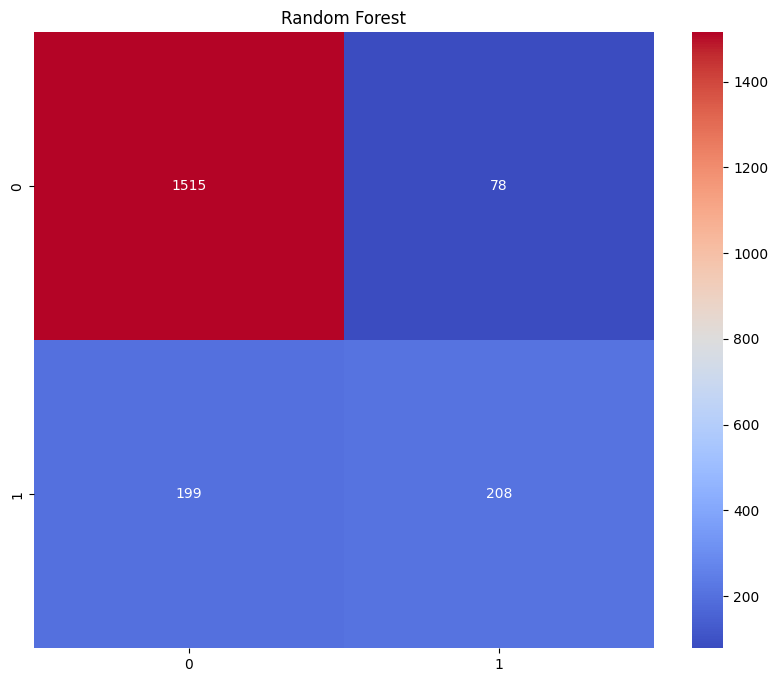

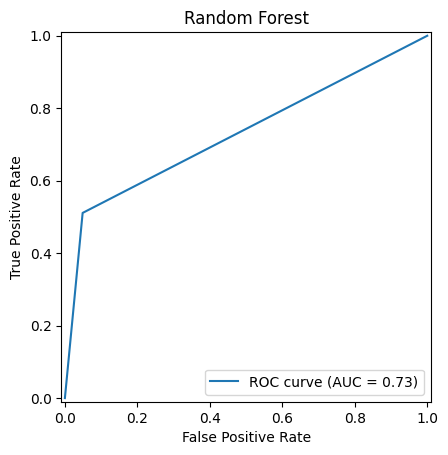

In [ ]:
rf_model = RandomForestClassifier( min_samples_split = 28, max_depth = 20,class_weight='balanced')
rf_model.fit(X_train_scaled, y_train_res)

y_pred = rf_model.predict(X_test_scaled)

# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = rf_model.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("Random Forest")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("Random Forest")
plt.show()

##K-NN Classifier

In [ ]:
param_grids = {'n_neighbors' : np.arange(1,30)}
knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grids, cv=5)
knn_gscv.fit(X_train_scaled, y_train_res)

knn_gscv.best_params_

{'n_neighbors': np.int64(1)}

Accuracy Score 0.814
Recall Score: 0.5724815724815725
Precision Score: 0.5406032482598608
F1 Score: 0.5560859188544153
ROC_AUC score: 0.8057633905091532
Classification report:
               precision    recall  f1-score   support

         0.0       0.89      0.88      0.88      1593
         1.0       0.54      0.57      0.56       407

    accuracy                           0.81      2000
   macro avg       0.71      0.72      0.72      2000
weighted avg       0.82      0.81      0.82      2000



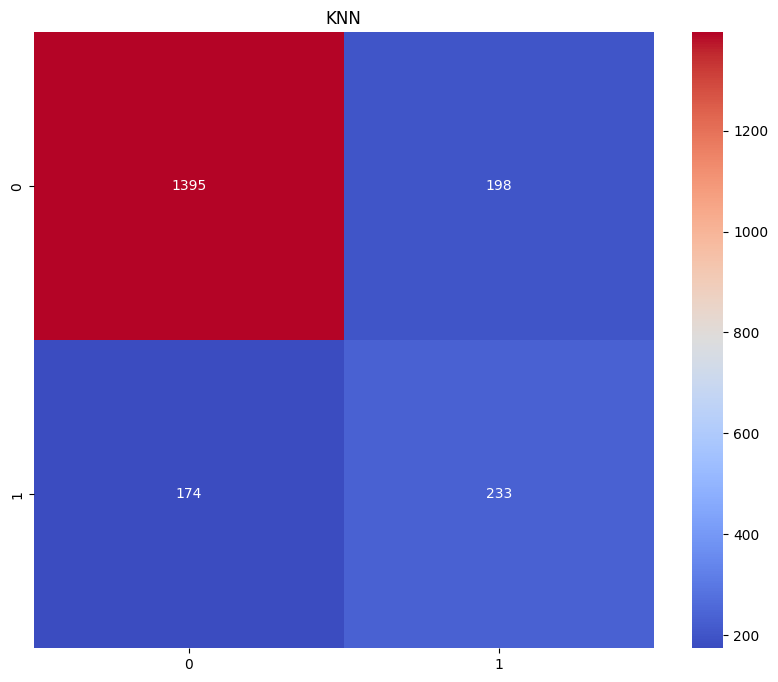

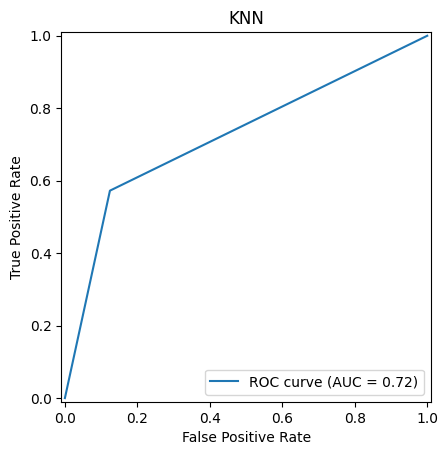

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 20 )
knn.fit(X_train_scaled, y_train_res)

y_pred = knn.predict(X_test_scaled)


# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = knn.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("KNN")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("KNN")
plt.show()

##XGBoost


Accuracy Score 0.824
Recall Score: 0.6805896805896806
Precision Score: 0.5551102204408818
F1 Score: 0.6114790286975718
ROC_AUC score: 0.8397318736301785
Classification report:
               precision    recall  f1-score   support

         0.0       0.91      0.86      0.89      1593
         1.0       0.56      0.68      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



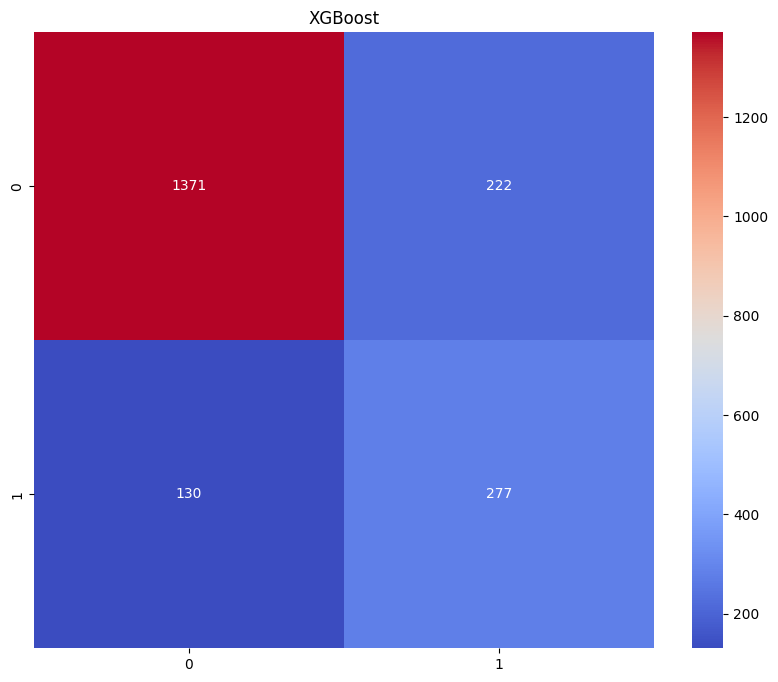

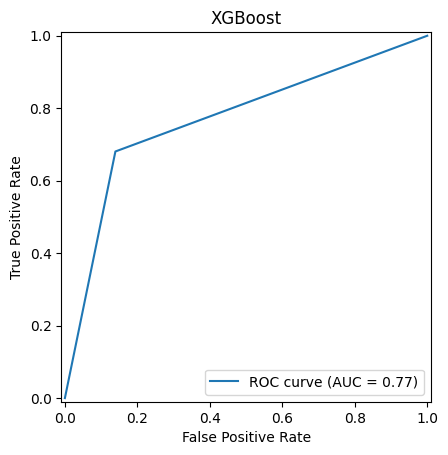

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=3.9
)
xgb.fit(X_train_scaled, y_train_res)

y_pred = xgb.predict(X_test_scaled)


# Accuracy score
print('Accuracy Score', accuracy_score(y_test, y_pred))

# Recall score
print('Recall Score:', recall_score(y_test, y_pred))

# Precision score
print('Precision Score:', precision_score(y_test, y_pred))

# F1-score score
print('F1 Score:', f1_score(y_test, y_pred))

# roc_auc score
probs = xgb.predict_proba(X_test_scaled)[:, 1]
print('ROC_AUC score:', roc_auc_score(y_test, probs))

# Classification report
print('Classification report:\n', classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap = 'coolwarm', annot = True, fmt = 'd')
plt.title("XGBoost")
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = 'ROC curve')
display.plot()
plt.title("XGBoost")
plt.show()

##Scores Analysis

> Add blockquote



In [ ]:
# Collect scores of all models in a single dataframe

results = {
    "Model": [
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "K-NN",
        "XGBoost"
    ],
    "Accuracy": [
        0.7140,
        0.8505,
        0.8330,
        0.8615,
        0.8140,
        0.8240
    ],
    "Precision": [
        0.3874,
        0.6579,
        0.6064,
        0.7289,
        0.5406,
        0.5551
    ],
    "Recall": [
        0.6978,
        0.5528,
        0.5111,
        0.5086,
        0.5725,
        0.6806
    ],
    "F1-Score": [
        0.4982,
        0.6008,
        0.5547,
        0.5991,
        0.5561,
        0.6115
    ],
    "ROC_AUC": [
        0.7774,
        0.8386,
        0.7997,
        0.8587,
        0.8057,
        0.8397
    ]
}

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace = True)
results_df.sort_values(by = ['ROC_AUC'], ascending = False)

,Accuracy,Precision,Recall,F1-Score,ROC_AUC
Model,,,,,
Random Forest,0.8615,0.7289,0.5086,0.5991,0.8587
XGBoost,0.8240,0.5551,0.6806,0.6115,0.8397
SVM,0.8505,0.6579,0.5528,0.6008,0.8386
K-NN,0.8140,0.5406,0.5725,0.5561,0.8057
Decision Tree,0.8330,0.6064,0.5111,0.5547,0.7997
Logistic Regression,0.7140,0.3874,0.6978,0.4982,0.7774


In [ ]:
# mean of all scores in each model
results_df.mean(axis = 1).sort_values(ascending = False)

,0
Model,
Random Forest,0.71136
XGBoost,0.70218
SVM,0.70012
Decision Tree,0.66098
K-NN,0.65778
Logistic Regression,0.61496


#Xulosa:
- Eng yaxshi model bu **XGBoost** boldi, chunki bu modelda accuracy, precision, va muhimi recall ham yaxshi chiqdi. Qolgan modellarda churn mijozni churn emas deb aniqlash holatlari koproq boldi. Garchi hamma modellarda churn emas(0) mijozlarni bashorat qilishda aniqlik yuqori bolsada, churn mijozlarni aniqlashda balans tufayli qiynaldi.
- Churn va Churn bo;lmagan mijozlar sonini balans qilish uchun X_train va y_trainlarga *SMOTE* funksiyasini qolladim. Bu XGBoost modeli aniqroq ishlashiga yordam berdi.
- Modellarni precision, recall, f1-score, accuracy va roc-auc score kabi metrikalardan foydalanish orqali baholadim.

#Bank uchun tavsiya:
- Credit card bolishi mijozning bankda qolishiga turtki bolishi mumkin, shu sabab mijozlarga credit card berish.
- O'rta yoshlik mijozlarni koproq jalb qilish ancha foydali.
- Active a'zolar orasida bankni tark etish ancha kam ekan, shuning uchun mijozlarni aktivlashtirish uchun turli xil tadbir va loyihalar amalga oshirish.

---

#Conclusion:
- XGBoost achieved the best overall performance, as it produced the highest accuracy, precision, and, most importantly, a good recall score. The other models were more likely to misclassify churn customers as non-churn customers. Although all models performed well in predicting non-churn (0) customers, they struggled to identify churn (1) customers due to the class imbalance in the dataset.
- To address the class imbalance, I applied SMOTE to the training data (X_train and y_train). This improved the model's ability to learn the minority class and helped XGBoost achieve better predictive performance.
- The models were evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score, to ensure a comprehensive and reliable comparison.

#Recommendations for the Bank
- Encourage customers to use credit cards, as having a credit card appears to increase customer retention and reduce the likelihood of churn.
- Focus on attracting and retaining middle-aged customers, as this age group tends to be more valuable and shows stronger customer loyalty.
- Increase customer engagement through loyalty programs, personalized offers, and promotional campaigns. Since active members are significantly less likely to leave the bank, encouraging customers to become more active can help reduce churn.